# Logistic Regression Model on Personal Transactions Data

Alisa Crowe

CS 549, Spring 2026

## Imports & Data Loading

In [1]:
import sys

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, make_scorer
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split

In [3]:
sys.path.insert(0, "../data")
from data_loading import load_train_test_split

X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)


train: (8644, 7) (8644,)
test:  (2162, 7) (2162,)


In [41]:
y_train.value_counts()

Category_Label
0    3056
1    2980
3    1864
2     538
4     206
Name: count, dtype: int64

## Baseline Model Training & Evaluation
### Baseline Model (No class weighting)

In [27]:
# define logistic regression model
clf1 = LogisticRegression(max_iter=2000)


In [29]:
# fit on training data
clf1.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
# evaluate on test data
y_pred = clf1.predict(X_test)

# print results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.36864014801110084
Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.53      0.44       764
           1       0.36      0.52      0.42       745
           2       0.78      0.05      0.10       135
           3       0.00      0.00      0.00       466
           4       0.00      0.00      0.00        52

    accuracy                           0.37      2162
   macro avg       0.30      0.22      0.19      2162
weighted avg       0.30      0.37      0.31      2162



/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [37]:
# classes 3 and 4 are not being predicted at all
np.unique(y_pred, return_counts=True)

(array([0, 1, 2]), array([1084, 1069,    9]))

### Baseline Model (Balanced classes)

In [48]:
clf2 = LogisticRegression(max_iter=2000, class_weight='balanced')

In [50]:
clf2.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [52]:
y_pred = clf2.predict(X_test)

# print results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.1887141535615171
Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.17      0.23       764
           1       0.36      0.13      0.20       745
           2       0.07      0.24      0.10       135
           3       0.23      0.29      0.26       466
           4       0.02      0.19      0.04        52

    accuracy                           0.19      2162
   macro avg       0.21      0.21      0.17      2162
weighted avg       0.30      0.19      0.21      2162



In [54]:
np.unique(y_pred, return_counts=True)

(array([0, 1, 2, 3, 4]), array([366, 279, 495, 591, 431]))

### Initial Findings

We will use balanced classes when tuning, training, and evaluating the model because although the accuracy decreases from 37% to 19%, classes 3 and 4 are not predicted without class weighting. To ensure the model learns about all classes, we will use balanced classes.

## Hyperparamter Tuning

### Regularization Selection with No Class Weighting

Training with C = 0.001
CV Acc: 0.3674, CV F1: 0.1773
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3709, CV F1: 0.2005
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3727, CV F1: 0.2014
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3688, CV F1: 0.1996
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3678, CV F1: 0.1991
--------------------------------------------------
Training with C = 1
CV Acc: 0.3678, CV F1: 0.1991
--------------------------------------------------
Training with C = 5
CV Acc: 0.3682, CV F1: 0.1993
--------------------------------------------------
Training with C = 10
CV Acc: 0.3685, CV F1: 0.1994
--------------------------------------------------
Training with C = 20
CV Acc: 0.3679, CV F1: 0.1991
--------------------------------------------------


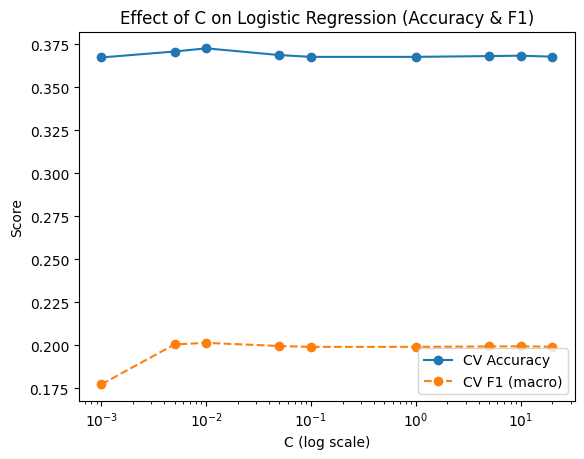

In [58]:
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10, 20]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C}")

    clf = LogisticRegression(max_iter=2000, C=C)
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1)')
plt.legend()

plt.show()

### Regularization Selection with Balanced Classes

Training with C = 0.001 (Balanced Classes)
CV Acc: 0.2075, CV F1: 0.1768
--------------------------------------------------
Training with C = 0.005 (Balanced Classes)
CV Acc: 0.2033, CV F1: 0.1782
--------------------------------------------------
Training with C = 0.01 (Balanced Classes)
CV Acc: 0.2010, CV F1: 0.1772
--------------------------------------------------
Training with C = 0.05 (Balanced Classes)
CV Acc: 0.1919, CV F1: 0.1714
--------------------------------------------------
Training with C = 0.1 (Balanced Classes)
CV Acc: 0.1904, CV F1: 0.1703
--------------------------------------------------
Training with C = 1 (Balanced Classes)
CV Acc: 0.1893, CV F1: 0.1695
--------------------------------------------------
Training with C = 5 (Balanced Classes)
CV Acc: 0.1893, CV F1: 0.1695
--------------------------------------------------
Training with C = 10 (Balanced Classes)
CV Acc: 0.1893, CV F1: 0.1696
--------------------------------------------------
Training with C = 20 (B

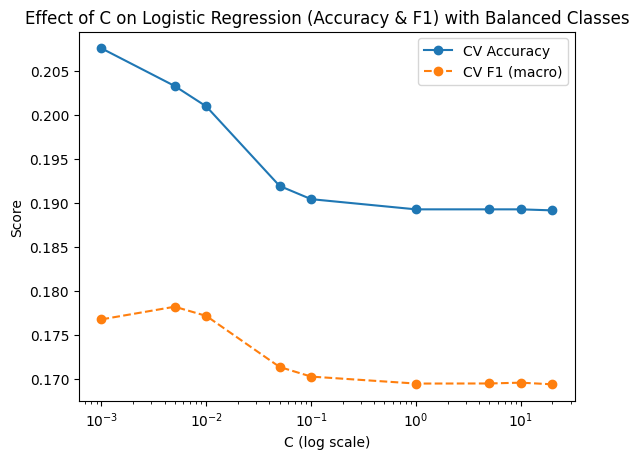

In [65]:
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10, 20]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C} (Balanced Classes)")

    clf = LogisticRegression(max_iter=2000, C=C, class_weight='balanced')
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1) with Balanced Classes')
plt.legend()

plt.show()

### Analysis of Regularization with Balanced/Unbalanced Classes

For unbalanced classes, C has minimal effect on accuracy and F1 performance, indicating that predictive features are weak or the data is not linearly separable. With balanced classes, performance spikes around C = 0.001 to 0.005, and decreases from there. This inidicates overfitting when the model is allowed more flexibility, and a need for a strong penalty term (small C). 

For either version, C does not have much effect on the performance of the model itself, indicating weak learners. We will work on featurization to try to introduce more informative features.

### Hyperparameter Tuning: L1 vs L2 Regularization


=== Penalty = 0, Class Weight = None ===
Training with C = 0.001
CV Acc: 0.3680, CV F1: 0.1776
Test Acc: 0.3788, Test F1: 0.1910
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3709, CV F1: 0.2005
Test Acc: 0.3714, Test F1: 0.1934
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3725, CV F1: 0.2013
Test Acc: 0.3700, Test F1: 0.1927
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3686, CV F1: 0.1995
Test Acc: 0.3696, Test F1: 0.1924
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3674, CV F1: 0.1989
Test Acc: 0.3696, Test F1: 0.1924
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3687, CV F1: 0.1995
Test Acc: 0.3696, Test F1: 0.1924
--------------------------------------------------
Training with C = 5
CV Acc: 0.3690, CV F1: 0.1997
Test Acc: 0.3696, Test F1: 0.1924
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3690, CV F1: 0.1997
Test Acc: 0.3696, Test F1: 0.1924
--------------------------------------------------
Training with C = 20


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3689, CV F1: 0.1996
Test Acc: 0.3696, Test F1: 0.1924
--------------------------------------------------

=== Penalty = 1, Class Weight = None ===
Training with C = 0.001
CV Acc: 0.3535, CV F1: 0.1045
Test Acc: 0.3534, Test F1: 0.1044
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3561, CV F1: 0.1202
Test Acc: 0.3562, Test F1: 0.1242
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3584, CV F1: 0.1550
Test Acc: 0.3774, Test F1: 0.1812
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3698, CV F1: 0.1998
Test Acc: 0.3714, Test F1: 0.1932
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3694, CV F1: 0.1997
Test Acc: 0.3723, Test F1: 0.1937
--------------------------------------------------
Training with C = 1
CV Acc: 0.3689, CV F1: 0.1996
Test Acc: 0.3710, Test F1: 0.1931
--------------------------------------------------
Training with C =

/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3687, CV F1: 0.1995
Test Acc: 0.3700, Test F1: 0.1927
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3689, CV F1: 0.1996
Test Acc: 0.3696, Test F1: 0.1924
--------------------------------------------------
Training with C = 20


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3689, CV F1: 0.1996
Test Acc: 0.3696, Test F1: 0.1924
--------------------------------------------------

=== Penalty = 0, Class Weight = Balanced ===
Training with C = 0.001
CV Acc: 0.2075, CV F1: 0.1772
Test Acc: 0.2017, Test F1: 0.1687
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.2028, CV F1: 0.1778
Test Acc: 0.1994, Test F1: 0.1717
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.2005, CV F1: 0.1768
Test Acc: 0.1961, Test F1: 0.1695
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.1924, CV F1: 0.1716
Test Acc: 0.1901, Test F1: 0.1658
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.1905, CV F1: 0.1704
Test Acc: 0.1887, Test F1: 0.1655
--------------------------------------------------
Training with C = 1
CV Acc: 0.1893, CV F1: 0.1696
Test Acc: 0.1896, Test F1: 0.1662
--------------------------------------------------
Training with

/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.2333, CV F1: 0.0795
Test Acc: 0.2664, Test F1: 0.1129
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.1193, CV F1: 0.0640
Test Acc: 0.1679, Test F1: 0.0831
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.1971, CV F1: 0.1487
Test Acc: 0.2350, Test F1: 0.1721
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.1984, CV F1: 0.1707
Test Acc: 0.1813, Test F1: 0.1561
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.1911, CV F1: 0.1686
Test Acc: 0.1846, Test F1: 0.1618
--------------------------------------------------
Training with C = 1
CV Acc: 0.1897, CV F1: 0.1696
Test Acc: 0.1887, Test F1: 0.1654
--------------------------------------------------
Training with C = 5
CV Acc: 0.1889, CV F1: 0.1692
Test Acc: 0.1883, Test F1: 0.1651
--------------------------------------------------
Training with C = 10
CV Acc: 0.1891, CV F1: 0.1694
Test Acc: 0.

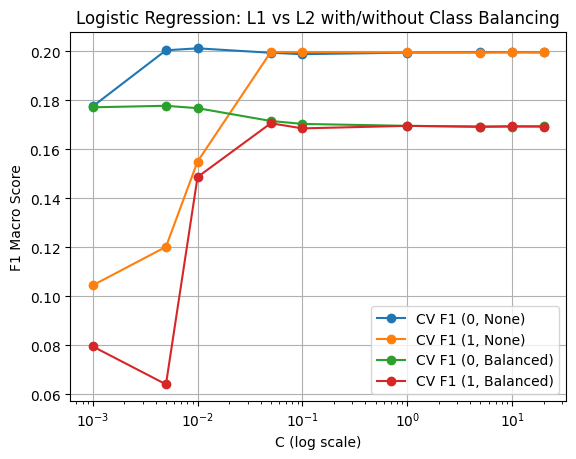


===== Class balance = None =====

0
CV Acc: [np.float64(0.368), np.float64(0.3709), np.float64(0.3725), np.float64(0.3686), np.float64(0.3674), np.float64(0.3687), np.float64(0.369), np.float64(0.369), np.float64(0.3689)]
CV F1 : [np.float64(0.1776), np.float64(0.2005), np.float64(0.2013), np.float64(0.1995), np.float64(0.1989), np.float64(0.1995), np.float64(0.1997), np.float64(0.1997), np.float64(0.1996)]
Test Acc: [0.3788, 0.3714, 0.37, 0.3696, 0.3696, 0.3696, 0.3696, 0.3696, 0.3696]
Test F1 : [0.191, 0.1934, 0.1927, 0.1924, 0.1924, 0.1924, 0.1924, 0.1924, 0.1924]

1
CV Acc: [np.float64(0.3535), np.float64(0.3561), np.float64(0.3584), np.float64(0.3698), np.float64(0.3694), np.float64(0.3689), np.float64(0.3687), np.float64(0.3689), np.float64(0.3689)]
CV F1 : [np.float64(0.1045), np.float64(0.1202), np.float64(0.155), np.float64(0.1998), np.float64(0.1997), np.float64(0.1996), np.float64(0.1995), np.float64(0.1996), np.float64(0.1996)]
Test Acc: [0.3534, 0.3562, 0.3774, 0.3714, 0.

In [78]:
# parameters to test
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10, 20]
l1_ratios = [0, 1] # 0 for l2, 1 for l1
class_weights = [None, 'balanced']

# store results
results = {}

for cw in class_weights:
    cw_label = 'None' if cw is None else 'Balanced'
    results[cw_label] = {}

    for ratio in l1_ratios:
        label = ratio

        cv_acc_scores = []
        cv_f1_scores = []
        test_acc_scores = []
        test_f1_scores = []

        print(f"\n=== Penalty = {label}, Class Weight = {cw_label} ===")

        for C in C_values:
            print(f"Training with C = {C}")

            clf = LogisticRegression(
                max_iter=2000,
                C=C,
                l1_ratio=ratio,
                class_weight=cw,
                solver='saga',
                random_state=42
            )

            # Cross-validation
            acc_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='accuracy'
            )

            f1_scores = cross_val_score(
                clf, X_train, y_train, cv=5, scoring='f1_macro'
            )

            cv_acc_scores.append(acc_scores.mean())
            cv_f1_scores.append(f1_scores.mean())

            # Train on full training set
            clf.fit(X_train, y_train)

            # Test evaluation
            y_pred = clf.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average='macro')

            test_acc_scores.append(test_acc)
            test_f1_scores.append(test_f1)

            print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
            print(f"Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
            print("-" * 50)

        results[cw_label][label] = {
            'cv_acc': cv_acc_scores,
            'cv_f1': cv_f1_scores,
            'test_acc': test_acc_scores,
            'test_f1': test_f1_scores
        }

# -------- Plot --------
plt.figure()

for cw_label in results:
    for label in results[cw_label]:
        plt.plot(
            C_values,
            results[cw_label][label]['cv_f1'],
            marker='o',
            label=f'CV F1 ({label}, {cw_label})'
        )

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('F1 Macro Score')
plt.title('Logistic Regression: L1 vs L2 with/without Class Balancing')
plt.legend()
plt.grid(True)

plt.savefig("logreg_full_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# -------- Print Results --------
for cw_label in results:
    print(f"\n===== Class balance = {cw_label} =====")
    for label in results[cw_label]:
        print(f"\n{label}")
        print("CV Acc:", [round(x, 4) for x in results[cw_label][label]['cv_acc']])
        print("CV F1 :", [round(x, 4) for x in results[cw_label][label]['cv_f1']])
        print("Test Acc:", [round(x, 4) for x in results[cw_label][label]['test_acc']])
        print("Test F1 :", [round(x, 4) for x in results[cw_label][label]['test_f1']])

### Analysis of Regularization Type

Regularization choices (L1 vs L2, C) have minimal impact compared to the limitations of the feature space and model capacity. This confirms a need for featurization.

## Feature Engineering
### Log Scale Amount Column before Standardization

In [141]:
df = pd.read_csv("../data/cleaned/transactions_cleaned_amount.csv")

In [143]:
df.head()

,Date,Amount,Transaction Type,Category,Day of Week,Month,Description_grouped,Desc_Amazon,Desc_Amazon Video,Desc_American Tavern,...,Desc_Thai Restaurant,Desc_Valero,Desc_Vietnamese Restaurant,Desc_Wendy's,Acct_Checking,Acct_Platinum Card,Acct_Silver Card,Category_label,Amount_log,Amount_log_scaled
0,2018-01-01,11.11,1,Shopping,0,1,Amazon,1,0,0,...,0,0,0,0,0,1,0,19,2.494032,-1.868738
1,2018-01-02,1247.44,1,Mortgage & Rent,1,1,Mortgage Payment,0,0,0,...,0,0,0,0,1,0,0,14,7.129650,2.878211
2,2018-01-02,24.22,1,Restaurants,1,1,Thai Restaurant,0,0,0,...,1,0,0,0,0,0,1,18,3.227637,-1.117514
3,2018-01-03,2298.09,0,Credit Card Payment,2,1,Credit Card Payment,0,0,0,...,0,0,0,0,0,1,0,3,7.740269,3.503495
4,2018-01-04,11.76,1,Movies & DVDs,3,1,Netflix,0,0,0,...,0,0,0,0,0,1,0,15,2.546315,-1.815199


In [145]:
feature_cols = (
    ["Transaction Type", "Day of Week", "Month", "Amount_log_scaled"]
    + [c for c in df.columns if c.startswith("Acct_")]
)
X = df[feature_cols]
y = df["Category_label"]

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of features:", len(feature_cols))

X_train shape: (8644, 7)
X_test shape: (2162, 7)
Number of features: 7


Training with C = 0.001
CV Acc: 0.1655, CV F1: 0.0165
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.1649, CV F1: 0.0194
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.1653, CV F1: 0.0203
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.1653, CV F1: 0.0209
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.1658, CV F1: 0.0210
--------------------------------------------------
Training with C = 1
CV Acc: 0.1666, CV F1: 0.0218
--------------------------------------------------
Training with C = 5


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.1668, CV F1: 0.0220
--------------------------------------------------


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


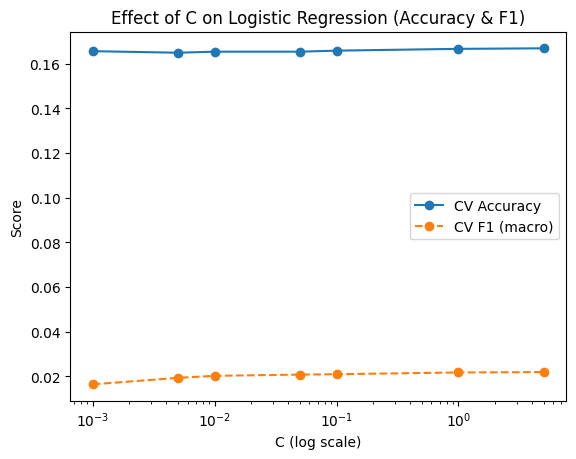

In [149]:
# no class weighting

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C}")

    clf = LogisticRegression(max_iter=2000, C=C, solver='saga', random_state=42)
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1)')
plt.legend()

plt.show()

Training with C = 0.001 (Balanced Classes)
CV Acc: 0.0236, CV F1: 0.0181
--------------------------------------------------
Training with C = 0.005 (Balanced Classes)
CV Acc: 0.0260, CV F1: 0.0192
--------------------------------------------------
Training with C = 0.01 (Balanced Classes)
CV Acc: 0.0263, CV F1: 0.0191
--------------------------------------------------
Training with C = 0.05 (Balanced Classes)
CV Acc: 0.0266, CV F1: 0.0212
--------------------------------------------------
Training with C = 0.1 (Balanced Classes)
CV Acc: 0.0263, CV F1: 0.0205
--------------------------------------------------
Training with C = 1 (Balanced Classes)
CV Acc: 0.0260, CV F1: 0.0206
--------------------------------------------------
Training with C = 5 (Balanced Classes)
CV Acc: 0.0260, CV F1: 0.0206
--------------------------------------------------


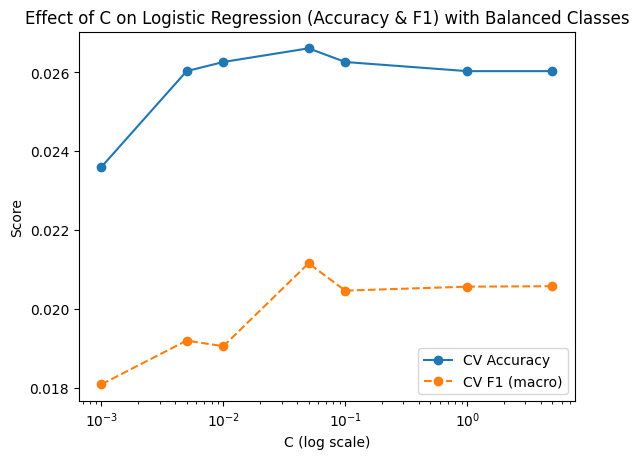

In [150]:
# balanced classes

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C} (Balanced Classes)")

    clf = LogisticRegression(max_iter=2000, C=C, class_weight='balanced', solver='saga', random_state=42)
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1) with Balanced Classes')
plt.legend()

plt.show()

In [151]:
np.unique(y_pred, return_counts=True)

(array([0, 1, 2, 3, 4]), array([367, 280, 494, 592, 429]))

Conclusion: Decrease in Acc & F1 - keep original Amount field 

### Experiment with Feature Engineering & Interaction Features

In [153]:
sys.path.insert(0, "../data")

from data_loading import load_train_test_split
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)

train: (8644, 7) (8644,)
test:  (2162, 7) (2162,)


#### 1. Add Season Feature from Month

In [155]:
def month_to_season(m):
    if m in [12, 1, 2]:
        return 0  # Winter
    elif m in [3, 4, 5]:
        return 1  # Spring
    elif m in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Fall

X_train["Season"] = X_train["Month"].apply(month_to_season)
X_test["Season"] = X_test["Month"].apply(month_to_season)

Training with C = 0.001
CV Acc: 0.3666, CV F1: 0.1769
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3709, CV F1: 0.2005
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3736, CV F1: 0.2018
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3686, CV F1: 0.1994
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3685, CV F1: 0.1994
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3688, CV F1: 0.1996
--------------------------------------------------
Training with C = 5
CV Acc: 0.3689, CV F1: 0.1996
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3689, CV F1: 0.1996
--------------------------------------------------


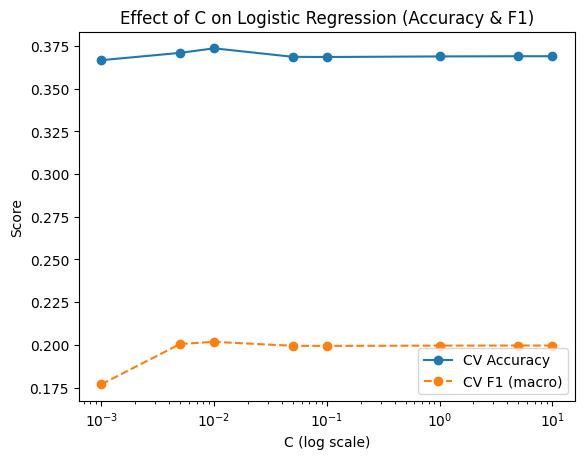

In [156]:
# no class weighting

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C}")

    clf = LogisticRegression(max_iter=2000, C=C, solver='saga', random_state=42)
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1)')
plt.legend()

plt.show()

Training with C = 0.001 (Balanced Classes)
CV Acc: 0.1993, CV F1: 0.1721
--------------------------------------------------
Training with C = 0.005 (Balanced Classes)
CV Acc: 0.1986, CV F1: 0.1744
--------------------------------------------------
Training with C = 0.01 (Balanced Classes)
CV Acc: 0.1942, CV F1: 0.1721
--------------------------------------------------
Training with C = 0.05 (Balanced Classes)
CV Acc: 0.1879, CV F1: 0.1680
--------------------------------------------------
Training with C = 0.1 (Balanced Classes)
CV Acc: 0.1866, CV F1: 0.1673
--------------------------------------------------
Training with C = 1 (Balanced Classes)
CV Acc: 0.1864, CV F1: 0.1672
--------------------------------------------------
Training with C = 5 (Balanced Classes)
CV Acc: 0.1868, CV F1: 0.1676
--------------------------------------------------


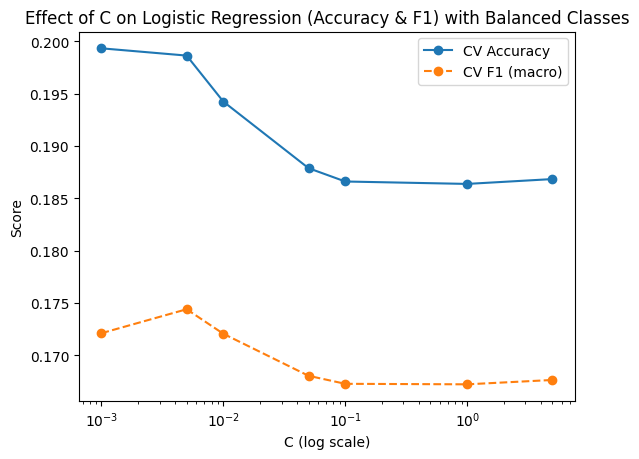

In [157]:
# balanced classes

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C} (Balanced Classes)")

    clf = LogisticRegression(max_iter=2000, C=C, class_weight='balanced')
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1) with Balanced Classes')
plt.legend()

plt.show()

Conclusion:

#### 2. Add Amount x Transaction Type

In [5]:
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

X_train["Amount_Transaction_Type"] = X_train["Amount_scaled"]*X_train["Transaction Type"]
X_test["Amount_Transaction_Type"] = X_test["Amount_scaled"]*X_test["Transaction Type"]

Training with C = 0.001
CV Acc: 0.3700, CV F1: 0.1851
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3683, CV F1: 0.1991
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3667, CV F1: 0.1984
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3668, CV F1: 0.1974
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3668, CV F1: 0.1975
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3671, CV F1: 0.1975
--------------------------------------------------
Training with C = 5
CV Acc: 0.3674, CV F1: 0.1977
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3675, CV F1: 0.1978
--------------------------------------------------


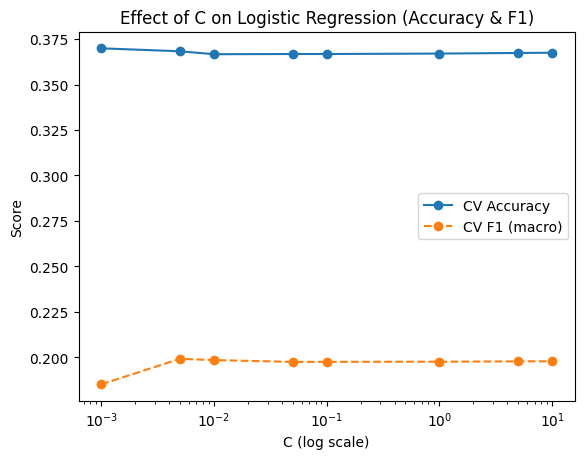

In [7]:
# no class weighting

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C}")

    clf = LogisticRegression(max_iter=2000, C=C, solver='saga', random_state=42)
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1)')
plt.legend()

plt.show()

Training with C = 0.001 (Balanced Classes)
CV Acc: 0.2087, CV F1: 0.1788
--------------------------------------------------
Training with C = 0.005 (Balanced Classes)
CV Acc: 0.2121, CV F1: 0.1836
--------------------------------------------------
Training with C = 0.01 (Balanced Classes)
CV Acc: 0.2068, CV F1: 0.1791
--------------------------------------------------
Training with C = 0.05 (Balanced Classes)
CV Acc: 0.2027, CV F1: 0.1754
--------------------------------------------------
Training with C = 0.1 (Balanced Classes)
CV Acc: 0.2027, CV F1: 0.1750
--------------------------------------------------
Training with C = 1 (Balanced Classes)
CV Acc: 0.2020, CV F1: 0.1744
--------------------------------------------------
Training with C = 5 (Balanced Classes)
CV Acc: 0.2015, CV F1: 0.1739
--------------------------------------------------


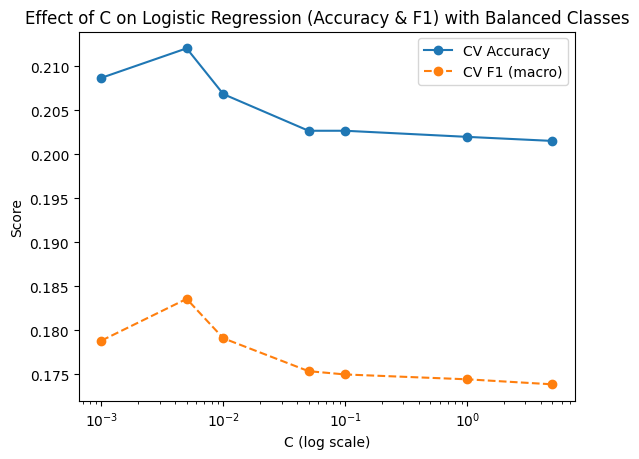

In [8]:
# balanced classes

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C} (Balanced Classes)")

    clf = LogisticRegression(max_iter=2000, C=C, class_weight='balanced')
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1) with Balanced Classes')
plt.legend()

plt.show()

#### 3. Add Amount x Account Type

In [13]:
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

account_cols = [
    "Acct_Platinum Card",
    "Acct_Checking",
    "Acct_Silver Card"
]

for col in account_cols:
    X_train[f"Amount_{col}"] = X_train["Amount_scaled"] * X_train[col]
    X_test[f"Amount_{col}"] = X_test["Amount_scaled"] * X_test[col]

X_train.head()

,Transaction Type,Day of Week,Month,Amount_scaled,Acct_Checking,Acct_Platinum Card,Acct_Silver Card,Amount_Acct_Platinum Card,Amount_Acct_Checking,Amount_Acct_Silver Card
3279,0,1,10,-0.110191,0,1,0,-0.110191,-0.000000,-0.000000
2882,0,2,3,-0.426278,0,1,0,-0.426278,-0.000000,-0.000000
3779,0,1,6,-0.199947,1,0,0,-0.000000,-0.199947,-0.000000
8962,0,5,3,-0.029880,0,1,0,-0.029880,-0.000000,-0.000000
8894,0,5,4,0.355848,0,0,1,0.000000,0.000000,0.355848


Training with C = 0.001
CV Acc: 0.3702, CV F1: 0.1994
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3723, CV F1: 0.2009
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3717, CV F1: 0.2007
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3704, CV F1: 0.2001
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3702, CV F1: 0.2000
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3686, CV F1: 0.1993
--------------------------------------------------
Training with C = 5


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3686, CV F1: 0.1993
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3686, CV F1: 0.1993
--------------------------------------------------


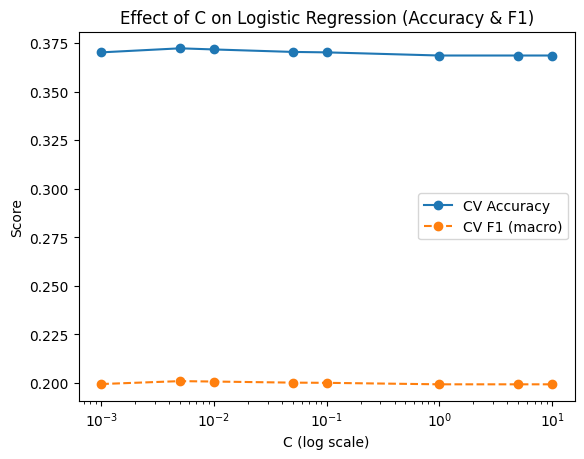

In [15]:
# no class weighting

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C}")

    clf = LogisticRegression(max_iter=2000, C=C, solver='saga', random_state=42)
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1)')
plt.legend()

plt.show()

Training with C = 0.001 (Balanced Classes)
CV Acc: 0.2143, CV F1: 0.1835
--------------------------------------------------
Training with C = 0.005 (Balanced Classes)
CV Acc: 0.2057, CV F1: 0.1790
--------------------------------------------------
Training with C = 0.01 (Balanced Classes)
CV Acc: 0.2012, CV F1: 0.1762
--------------------------------------------------
Training with C = 0.05 (Balanced Classes)
CV Acc: 0.1983, CV F1: 0.1728
--------------------------------------------------
Training with C = 0.1 (Balanced Classes)
CV Acc: 0.1976, CV F1: 0.1719
--------------------------------------------------
Training with C = 1 (Balanced Classes)
CV Acc: 0.1961, CV F1: 0.1698
--------------------------------------------------
Training with C = 5 (Balanced Classes)
CV Acc: 0.1956, CV F1: 0.1696
--------------------------------------------------


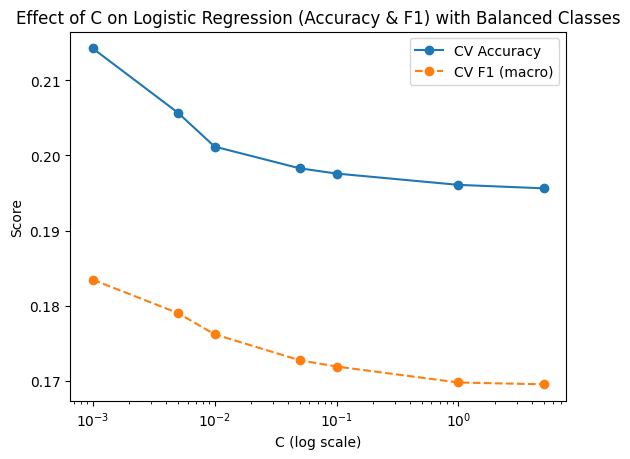

In [16]:
# balanced classes

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C} (Balanced Classes)")

    clf = LogisticRegression(max_iter=2000, C=C, class_weight='balanced')
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1) with Balanced Classes')
plt.legend()

plt.show()

#### 4. Add Day of Week x Transaction Type

In [18]:
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

X_train["Day_Transaction_Type"] = X_train["Day of Week"]*X_train["Transaction Type"]
X_test["Day_Transaction_Type"] = X_test["Day of Week"]*X_test["Transaction Type"]

Training with C = 0.001
CV Acc: 0.3611, CV F1: 0.1731
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3686, CV F1: 0.1993
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3686, CV F1: 0.1994
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3686, CV F1: 0.1995
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3685, CV F1: 0.1994
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3680, CV F1: 0.1992
--------------------------------------------------
Training with C = 5
CV Acc: 0.3679, CV F1: 0.1992
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3679, CV F1: 0.1992
--------------------------------------------------


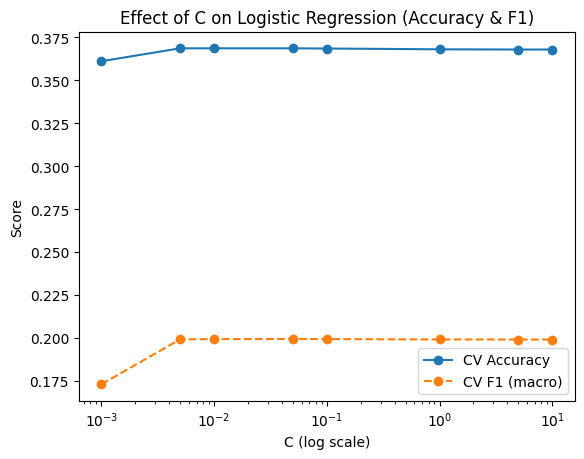

In [19]:
# no class weighting

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C}")

    clf = LogisticRegression(max_iter=2000, C=C, solver='saga', random_state=42)
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1)')
plt.legend()

plt.show()

Training with C = 0.001 (Balanced Classes)
CV Acc: 0.1797, CV F1: 0.1570
--------------------------------------------------
Training with C = 0.005 (Balanced Classes)
CV Acc: 0.1927, CV F1: 0.1691
--------------------------------------------------
Training with C = 0.01 (Balanced Classes)
CV Acc: 0.1940, CV F1: 0.1714
--------------------------------------------------
Training with C = 0.05 (Balanced Classes)
CV Acc: 0.1882, CV F1: 0.1681
--------------------------------------------------
Training with C = 0.1 (Balanced Classes)
CV Acc: 0.1872, CV F1: 0.1675
--------------------------------------------------
Training with C = 1 (Balanced Classes)
CV Acc: 0.1864, CV F1: 0.1671
--------------------------------------------------
Training with C = 5 (Balanced Classes)
CV Acc: 0.1859, CV F1: 0.1665
--------------------------------------------------


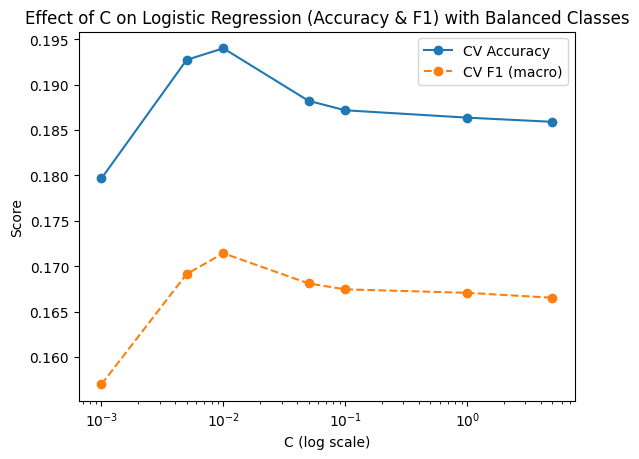

In [20]:
# balanced classes

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C} (Balanced Classes)")

    clf = LogisticRegression(max_iter=2000, C=C, class_weight='balanced')
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1) with Balanced Classes')
plt.legend()

plt.show()

#### 5. Add Weekend Indicator

In [22]:
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

X_train["Is_Weekend"] = X_train["Day of Week"].isin([5, 6]).astype(int)
X_test["Is_Weekend"] = X_test["Day of Week"].isin([5, 6]).astype(int)

Training with C = 0.001
CV Acc: 0.3668, CV F1: 0.1770
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3701, CV F1: 0.2001
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3700, CV F1: 0.2001
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3701, CV F1: 0.2002
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3696, CV F1: 0.2000
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3699, CV F1: 0.2001
--------------------------------------------------
Training with C = 5
CV Acc: 0.3699, CV F1: 0.2001
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3696, CV F1: 0.2000
--------------------------------------------------


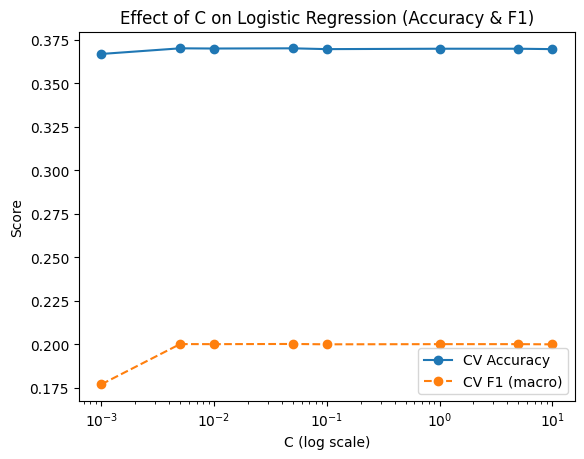

In [23]:
# no class weighting

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C}")

    clf = LogisticRegression(max_iter=2000, C=C, solver='saga', random_state=42)
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1)')
plt.legend()

plt.show()

Training with C = 0.001 (Balanced Classes)
CV Acc: 0.2069, CV F1: 0.1772
--------------------------------------------------
Training with C = 0.005 (Balanced Classes)
CV Acc: 0.2031, CV F1: 0.1779
--------------------------------------------------
Training with C = 0.01 (Balanced Classes)
CV Acc: 0.2003, CV F1: 0.1771
--------------------------------------------------
Training with C = 0.05 (Balanced Classes)
CV Acc: 0.1907, CV F1: 0.1706
--------------------------------------------------
Training with C = 0.1 (Balanced Classes)
CV Acc: 0.1894, CV F1: 0.1699
--------------------------------------------------
Training with C = 1 (Balanced Classes)
CV Acc: 0.1890, CV F1: 0.1700
--------------------------------------------------
Training with C = 5 (Balanced Classes)
CV Acc: 0.1890, CV F1: 0.1700
--------------------------------------------------


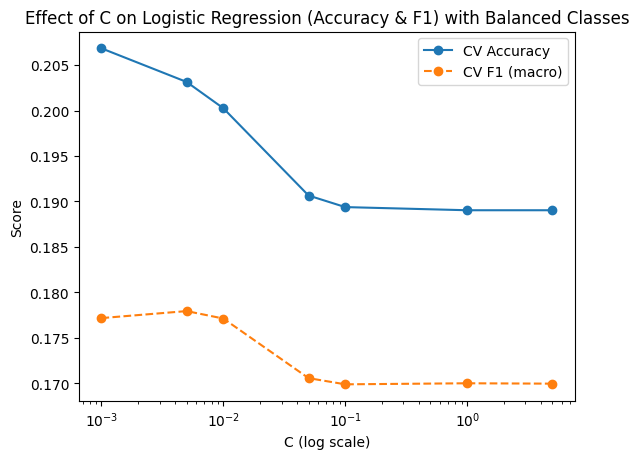

In [24]:
# balanced classes

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C} (Balanced Classes)")

    clf = LogisticRegression(max_iter=2000, C=C, class_weight='balanced')
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1) with Balanced Classes')
plt.legend()

plt.show()

#### 6. Add Sine Function for Day of Week

In [26]:
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

X_train["Day_sin"] = np.sin(2 * np.pi * X_train["Day of Week"] / 7)
X_test["Day_sin"] = np.sin(2 * np.pi * X_test["Day of Week"] / 7)

Training with C = 0.001
CV Acc: 0.3696, CV F1: 0.1784
--------------------------------------------------
Training with C = 0.005
CV Acc: 0.3695, CV F1: 0.1998
--------------------------------------------------
Training with C = 0.01
CV Acc: 0.3688, CV F1: 0.1995
--------------------------------------------------
Training with C = 0.05
CV Acc: 0.3683, CV F1: 0.1994
--------------------------------------------------
Training with C = 0.1
CV Acc: 0.3680, CV F1: 0.1992
--------------------------------------------------
Training with C = 1


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

CV Acc: 0.3668, CV F1: 0.1987
--------------------------------------------------
Training with C = 5
CV Acc: 0.3673, CV F1: 0.1989
--------------------------------------------------
Training with C = 10


/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/alisacrowe/Desktop/CS 549/cs549s26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CV Acc: 0.3673, CV F1: 0.1989
--------------------------------------------------


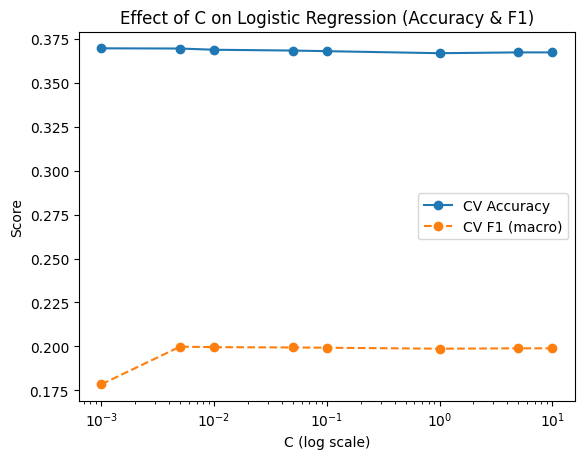

In [27]:
# no class weighting

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C}")

    clf = LogisticRegression(max_iter=2000, C=C, solver='saga', random_state=42)
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1)')
plt.legend()

plt.show()

Training with C = 0.001 (Balanced Classes)
CV Acc: 0.2111, CV F1: 0.1823
--------------------------------------------------
Training with C = 0.005 (Balanced Classes)
CV Acc: 0.2073, CV F1: 0.1802
--------------------------------------------------
Training with C = 0.01 (Balanced Classes)
CV Acc: 0.2013, CV F1: 0.1767
--------------------------------------------------
Training with C = 0.05 (Balanced Classes)
CV Acc: 0.1954, CV F1: 0.1734
--------------------------------------------------
Training with C = 0.1 (Balanced Classes)
CV Acc: 0.1949, CV F1: 0.1732
--------------------------------------------------
Training with C = 1 (Balanced Classes)
CV Acc: 0.1933, CV F1: 0.1719
--------------------------------------------------
Training with C = 5 (Balanced Classes)
CV Acc: 0.1931, CV F1: 0.1717
--------------------------------------------------


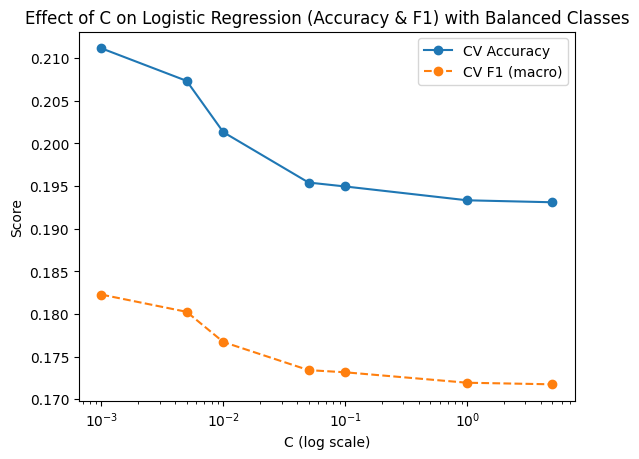

In [28]:
# balanced classes

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5]

cv_acc_scores = []
cv_f1_scores = []

test_acc_scores = []
test_f1_scores = []

for C in C_values:
    print(f"Training with C = {C} (Balanced Classes)")

    clf = LogisticRegression(max_iter=2000, C=C, class_weight='balanced')
    clf.fit(X_train, y_train)

    # cross-validation scores
    acc_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro')

    cv_acc_scores.append(acc_scores.mean())
    cv_f1_scores.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

# plotting
plt.figure()

# cross-validation curves
plt.plot(C_values, cv_acc_scores, marker='o', label='CV Accuracy')
plt.plot(C_values, cv_f1_scores, marker='o', linestyle='--', label='CV F1 (macro)')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Score')
plt.title('Effect of C on Logistic Regression (Accuracy & F1) with Balanced Classes')
plt.legend()

plt.show()